# Huấn luyện mô hình XGBoost cho Invoice Total

Notebook này sẽ đọc file `xgboost_dataset.csv` đã trích xuất đặc trưng (features) từ SROIE, sau đó huấn luyện một mô hình XGBoost để phân loại đâu là số Tổng Tiền (Grand Total).

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Tải Dataset
csv_path = "xgboost_dataset.csv"
df = pd.read_csv(csv_path)
print(f"Đã tải {len(df)} ứng viên (candidates).")
df.head()

Đã tải 20144 ứng viên (candidates).


,semantic_sim,normalized_y,is_max,text_length,has_currency,label
0,0.000000,0.200697,0.0,37,0.0,0
1,0.372889,0.200697,0.0,14,0.0,0
2,0.282960,0.250498,0.0,34,0.0,0
3,0.000000,0.274651,0.0,13,0.0,0
4,0.025197,0.274651,0.0,7,0.0,0


In [2]:
# 2. Xử lý Dữ Liệu
# Tách Features (X) và Label (y)
X = df[["semantic_sim", "normalized_y", "is_max", "text_length", "has_currency"]]
y = df["label"]

# Chia Train/Test (80% huấn luyện, 20% kiểm tra)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tập huấn luyện: {len(X_train)} mẫu (Positive: {sum(y_train)})")
print(f"Tập kiểm thử: {len(X_test)} mẫu (Positive: {sum(y_test)})")

Tập huấn luyện: 16115 mẫu (Positive: 1186)
Tập kiểm thử: 4029 mẫu (Positive: 297)


In [3]:
# 3. Tính toán trọng số mất cân bằng (Class Imbalance)
# Vì trong 1 tờ hóa đơn chỉ có 1 số là Tổng Tiền (label=1), còn lại đều là 0, dữ liệu bị lệch rất nặng.
# scale_pos_weight giúp XGBoost tập trung vào các nhãn 1 (Tổng Tiền) nhiều hơn.
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_weight = neg_count / pos_count

print(f"Tỷ lệ lệch nhãn (0 so với 1): {scale_weight:.2f}")

# Khởi tạo mô hình
xgb_model = xgb.XGBClassifier(
    n_estimators=200,          # Số lượng cây quyết định (tăng để học sâu hơn)
    max_depth=5,               # Độ sâu tối đa của cây (tránh overfitting)
    learning_rate=0.05,        # Tốc độ học
    scale_pos_weight=scale_weight, # Cân bằng dữ liệu lệch
    eval_metric="logloss",
    random_state=42
)

# Huấn luyện
print("🚀 Đang huấn luyện XGBoost...")
xgb_model.fit(X_train, y_train)
print("✅ Huấn luyện hoàn tất!")

Tỷ lệ lệch nhãn (0 so với 1): 12.59
🚀 Đang huấn luyện XGBoost...
✅ Huấn luyện hoàn tất!



--- BÁO CÁO ĐỘ CHÍNH XÁC ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      3732
           1       0.23      0.76      0.36       297

    accuracy                           0.80      4029
   macro avg       0.61      0.78      0.62      4029
weighted avg       0.92      0.80      0.84      4029



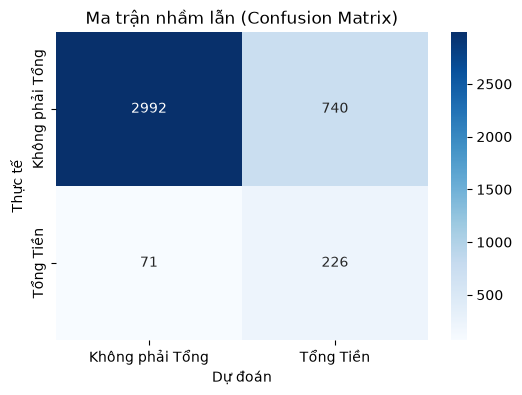

In [4]:
# 4. Đánh giá Mô Hình (Evaluation)
y_pred = xgb_model.predict(X_test)

print("\n--- BÁO CÁO ĐỘ CHÍNH XÁC ---")
print(classification_report(y_test, y_pred))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Không phải Tổng", "Tổng Tiền"], yticklabels=["Không phải Tổng", "Tổng Tiền"])
plt.ylabel("Thực tế")
plt.xlabel("Dự đoán")
plt.title("Ma trận nhầm lẫn (Confusion Matrix)")
plt.show()

In [5]:
# 5. Lưu mô hình để tích hợp vào Pipeline
model_dir = ".."
os.makedirs(model_dir, exist_ok=True)
save_path = os.path.join(model_dir, "xgb_total_model.json")

xgb_model.save_model(save_path)
print(f"💾 Đã lưu mô hình XGBoost siêu nhẹ tại: {save_path}")

💾 Đã lưu mô hình XGBoost siêu nhẹ tại: ..\xgb_total_model.json
